In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from config import BENCHMARKS
from utils import plot_pool_distribution
from sensitivity_analysis.sensitivity_utils import load_scores, sweep_thresholds, plot_sweep

BENCHMARK = "SEASON"
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
METRIC_COL = BENCH_PARAMS["metric_col"]
THRESHOLD = BENCH_PARAMS["threshold"]
METRIC_OP = BENCH_PARAMS["metric_op"]
SAMPLE_SIZE = BENCH_PARAMS["sample_size"]
SPARSITY_MIN = BENCH_PARAMS["sparsity_min"]
XLABEL = "Max Seasonal Strength (daily vs weekly)"

SOURCES = [
    ("institutions", "Institutions"),
    ("subnets", "Subnets"),
    ("ips_full", "IPs"),
]

SWEEP_RANGE = np.arange(0.50, 0.91, 0.05)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('sensitivity_analysis/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Benchmark: {BENCHMARK}")
print(f"Threshold: {METRIC_COL} {METRIC_OP} {THRESHOLD}")
print(f"Sparsity filter: ratio_active >= {SPARSITY_MIN}")
print(f"Sample size: {SAMPLE_SIZE}")

Benchmark: SEASON
Threshold: max_strength >= 0.7
Sparsity filter: ratio_active >= 0.4
Sample size: 25


## Hourly

In [2]:
print("Loading hourly scores:")
scores_hourly_raw = load_scores("hourly", BENCHMARK, SOURCES)

scores_hourly = {}
for label, df in scores_hourly_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_hourly[label] = filtered

Loading hourly scores:
  Institutions: 283 series
  Subnets: 548 series
  IPs: 275124 series
  Institutions: 281/283 pass sparsity >= 0.4
  Subnets: 535/548 pass sparsity >= 0.4
  IPs: 42706/275124 pass sparsity >= 0.4


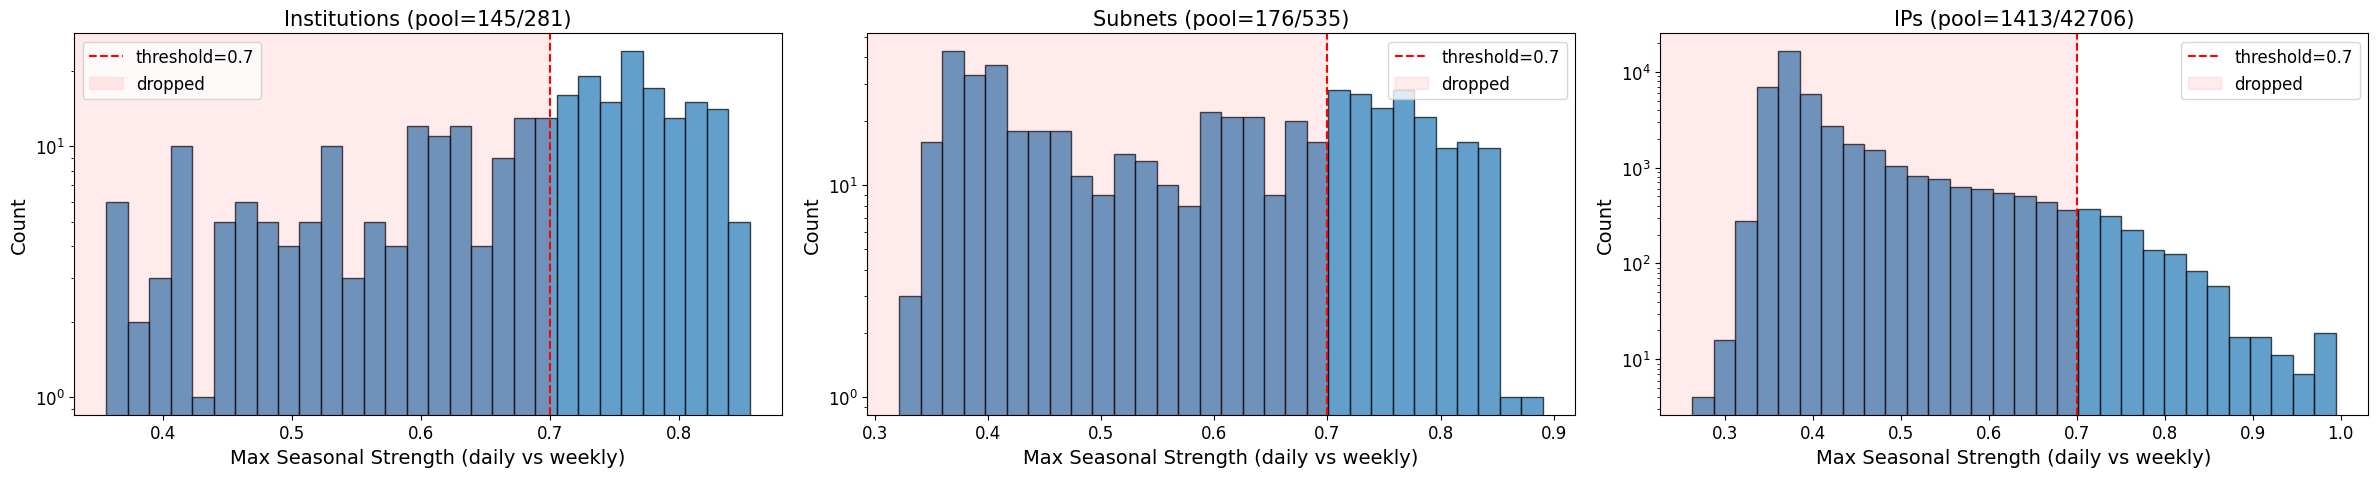

In [3]:
plot_pool_distribution(
    [(scores_hourly[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_hourly.pdf",
)

In [4]:
sweep_hourly = sweep_thresholds(scores_hourly, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_hourly)

,threshold,Institutions pool,Institutions median,Subnets pool,Subnets median,IPs pool,IPs median
0,0.50,240,0.724,334,0.708,6255,0.608
1,0.55,221,0.732,302,0.718,4618,0.646
2,0.60,207,0.736,274,0.727,3318,0.683
3,0.65,174,0.756,217,0.746,2238,0.719
4,0.70,145,0.764,176,0.762,1413,0.750
5,0.75,90,0.792,102,0.794,703,0.798
6,0.80,36,0.827,43,0.831,336,0.836
7,0.85,1,0.855,4,0.854,127,0.878
8,0.90,0,NaN,0,NaN,51,0.947


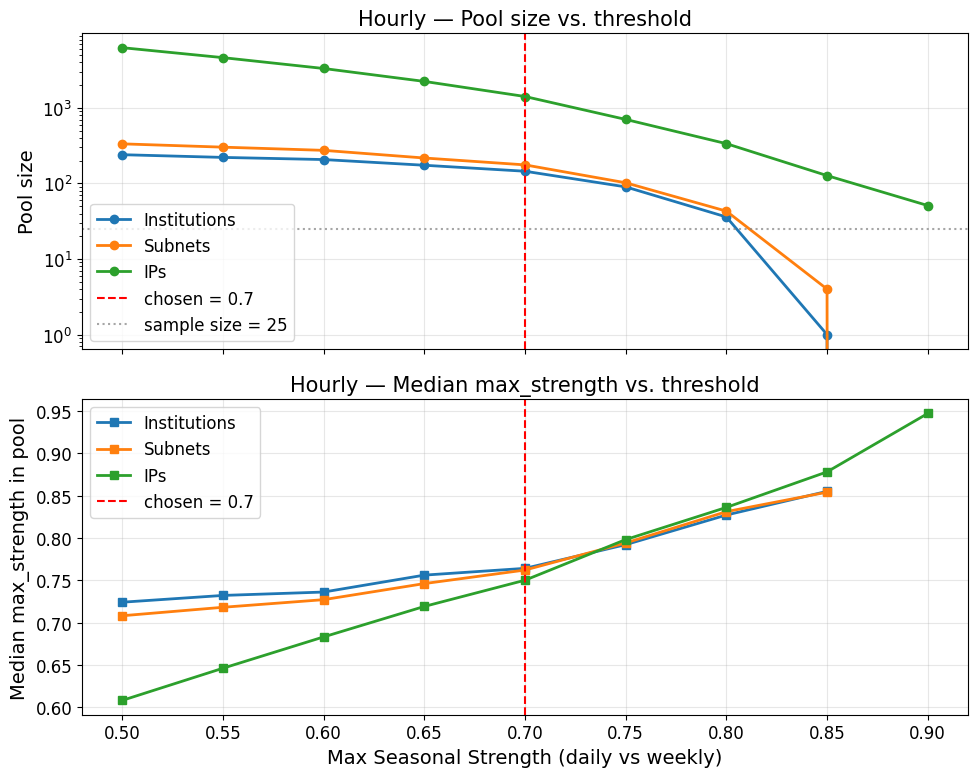

In [5]:
plot_sweep(sweep_hourly, "Hourly", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_hourly.pdf", log_y=True)

## 10-Minute

In [6]:
print("Loading 10-minute scores:")
scores_10min_raw = load_scores("10min", BENCHMARK, SOURCES)

scores_10min = {}
for label, df in scores_10min_raw.items():
    filtered = df[df["ratio_active"] >= SPARSITY_MIN].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass sparsity >= {SPARSITY_MIN}")
    scores_10min[label] = filtered

Loading 10-minute scores:
  Institutions: 283 series
  Subnets: 548 series
  IPs: 275124 series
  Institutions: 266/283 pass sparsity >= 0.4
  Subnets: 468/548 pass sparsity >= 0.4
  IPs: 34729/275124 pass sparsity >= 0.4


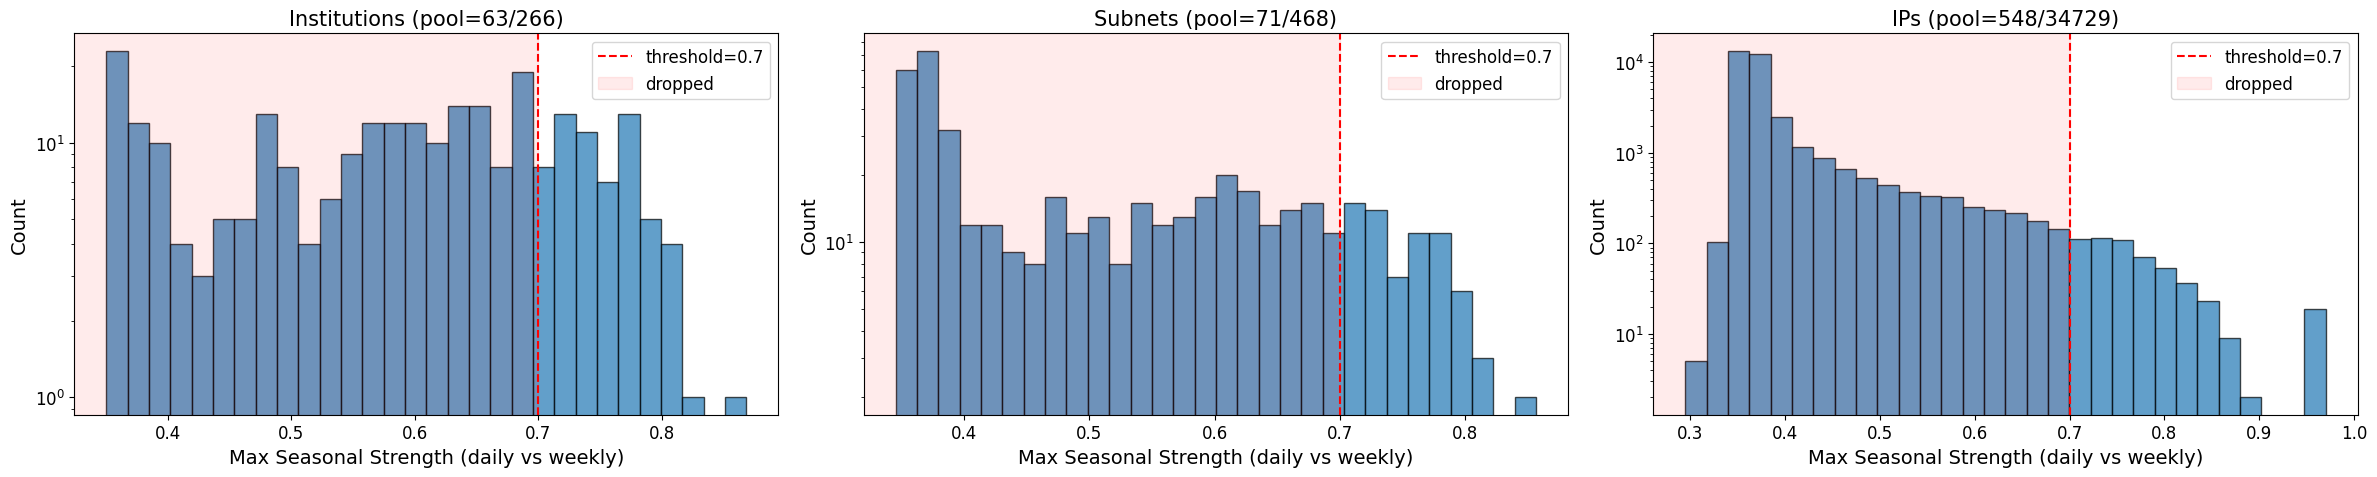

In [7]:
plot_pool_distribution(
    [(scores_10min[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_10min.pdf",
)

In [8]:
sweep_10min = sweep_thresholds(scores_10min, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_10min)

,threshold,Institutions pool,Institutions median,Subnets pool,Subnets median,IPs pool,IPs median
0,0.50,186,0.658,234,0.647,3009,0.593
1,0.55,167,0.673,199,0.662,2116,0.635
2,0.60,138,0.689,160,0.687,1427,0.675
3,0.65,97,0.722,110,0.720,910,0.719
4,0.70,63,0.748,71,0.748,548,0.754
5,0.75,30,0.778,33,0.780,292,0.789
6,0.80,5,0.813,6,0.811,113,0.831
7,0.85,1,0.869,1,0.857,36,0.963
8,0.90,0,NaN,0,NaN,20,0.967


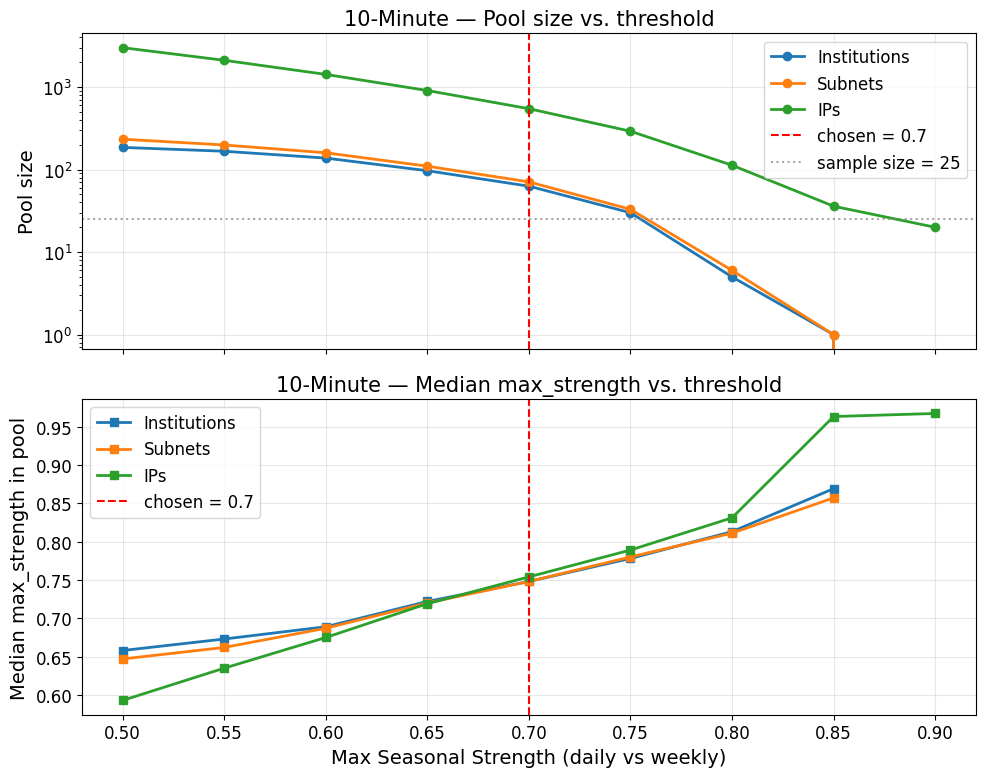

In [9]:
plot_sweep(sweep_10min, "10-Minute", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_10min.pdf", log_y=True)